In [1]:
from inception.instruments import FullTensorInterpolator, AutoCallableNoteChebyshev
from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.instruments import Stock, Portfolio
from inception.instruments.meta_instrument import Greeks

from env.environment import TradingEnv
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
from pandas_datareader import data as pdr

import yfinance as yf
yf.pdr_override() # <== that's all it takes :-)

# download dataframe
data_dia = pdr.get_data_yahoo("DIA", start="2014-01-01", end="2024-03-01")
data_spy = pdr.get_data_yahoo("SPY", start="2014-01-01", end="2024-03-01")
data_xlv = pdr.get_data_yahoo("XLV", start="2014-01-01", end="2024-03-01")

log_return = np.c_[np.diff(np.log(data_dia.Close)), np.diff(np.log(data_spy.Close)), np.diff(np.log(data_xlv.Close))]
log_df = pd.DataFrame(log_return)
corr_matrix = np.corrcoef(log_df.T)
corr_matrix

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


array([[1.        , 0.95951808, 0.82093145],
       [0.95951808, 1.        , 0.83370277],
       [0.82093145, 0.83370277, 1.        ]])

In [3]:
stock_price=[382.82, 494.08, 142.864]
evaluate_date='2024-02-14'

start_date = '2024-02-14'
issued_price = [382.82, 494.08, 142.86]
index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
stock_name = ['A', 'B', 'C']
stock_mean = [0.05, 0.05, 0.05]

In [4]:
notes_database = './one_year_chebyshev_database/'
interpolator = FullTensorInterpolator(notes_database)
parameters = NOTES_PARAMETERS['Multi Assets One Year']

notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                    evaluate_date=evaluate_date,
                                    underlying_names=stock_name,
                                    stock_price=stock_price,
                                    vol=index_vol,
                                    issue_price=issued_price,
                                    note_interpolator=interpolator,
                                    valuation_dates=parameters['valuation dates'],
                                    call_dates=parameters['call dates'],
                                    coupon_payment_dates=parameters['coupon dates'],
                                    coupon_barrier=parameters['coupon barrier'],
                                    call_barrier=parameters['call barrier'],
                                    principal_barrier=parameters['principal barrier'],
                                    coupon_amount=parameters['coupon amount'],
                                    free_rate=risk_free_rate,
                                    volume=-1)

t1 = time.time()
print('Value :', notes_c.value)
print('Delta :', notes_c.delta)
print('Gamma :', notes_c.gamma)
print(f'Total time: {time.time() - t1}')

Value : -100.54377644299535
Delta : A: -0.011925219398528654, B: -0.008568448196550813, C: -0.04499058494361515
Gamma : A: 0.0012257826531320726, B: 0.0007378273670104045, C: 0.006775945886701209
Total time: 0.01562976837158203


The 0th variable is 421.39, and larger than the upper bound 421.10200000000003
The 0th variable is 421.39, and larger than the upper bound 421.10200000000003
The 0th variable is 421.39, and larger than the upper bound 421.10200000000003
The 0th variable is 421.98, and larger than the upper bound 421.10200000000003
The 0th variable is 421.98, and larger than the upper bound 421.10200000000003
The 0th variable is 421.98, and larger than the upper bound 421.10200000000003
The 0th variable is 423.36, and larger than the upper bound 421.10200000000003
The 0th variable is 423.36, and larger than the upper bound 421.10200000000003
The 0th variable is 423.36, and larger than the upper bound 421.10200000000003
The 0th variable is 421.40000000000003, and larger than the upper bound 421.10200000000003
The 0th variable is 421.40000000000003, and larger than the upper bound 421.10200000000003
The 0th variable is 421.40000000000003, and larger than the upper bound 421.10200000000003
The 1th variable

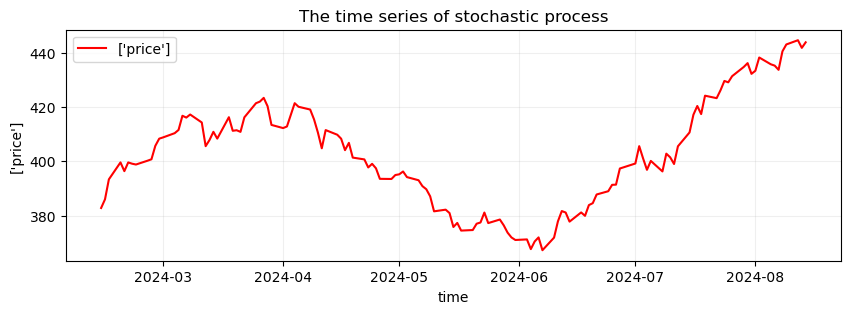

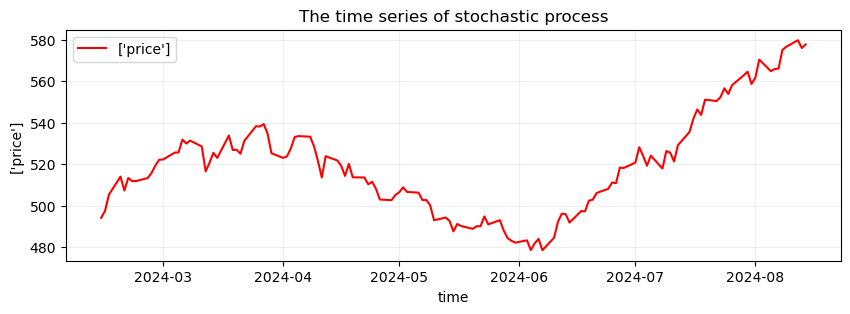

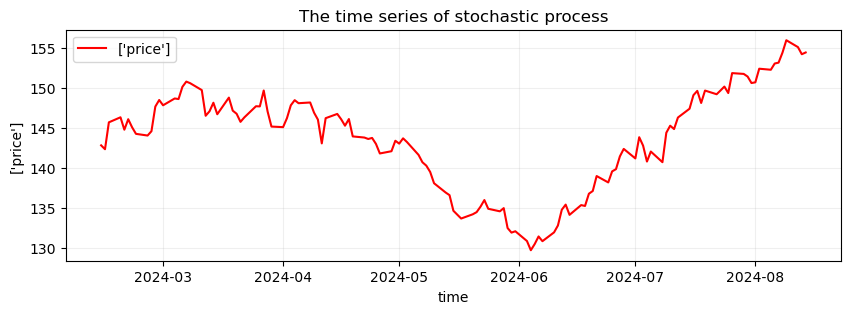

In [5]:
stock_A = Stock(stock_price[0], stock_mean[0], index_vol[0], evaluate_date, jump_weekend=True, name=stock_name[0],
                seed=0)
stock_B = Stock(stock_price[1], stock_mean[1], index_vol[1], evaluate_date, jump_weekend=True, name=stock_name[1],
                correlation=0.96, seed=1)
stock_C = Stock(stock_price[2], stock_mean[2], index_vol[2], evaluate_date, jump_weekend=True, name=stock_name[2],
                correlation=0.82, seed=2)

portfolio = Portfolio()

[stock_A.attach(stock) for stock in [stock_B, stock_C]]
[stock.attach(notes_c) for stock in [stock_A, stock_B, stock_C]]
notes_c.attach(portfolio)

for _ in range(1500):
    stock_A.update()
    if notes_c.is_expired:
        break
    
stock_A.draw('price')
stock_B.draw('price')
stock_C.draw('price')


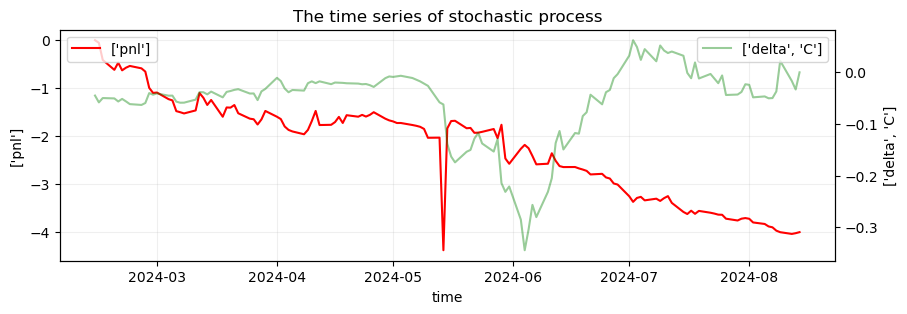

In [6]:
portfolio.draw('pnl', 'delta.C')

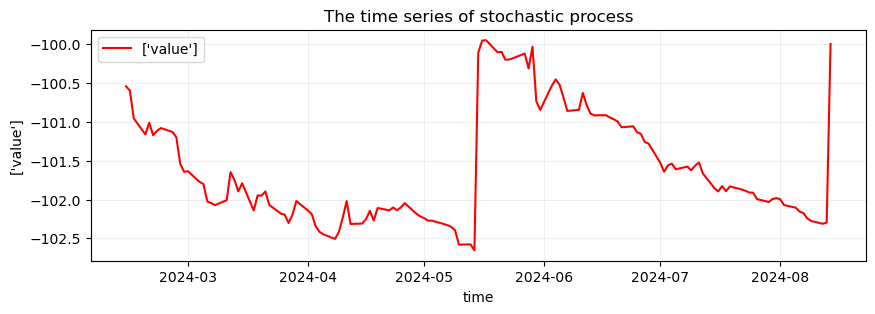

In [7]:
notes_c.draw('value')

## No Hedging Simulation

In [8]:
hedge_option_tenor = 30
transaction_cost = 0.02

trading_env = TradingEnv(stock_mean,
                         index_vol, 
                         stock_price, 
                         stock_name,
                         start_date,
                         risk_free_rate,
                         [],
                         [1],
                         hedge_option_tenor,
                         parameters['valuation dates'],
                         parameters['coupon dates'],
                         parameters['call dates'],
                         parameters['coupon barrier'],
                         parameters['principal barrier'],
                         parameters['call barrier'],
                         parameters['coupon amount'],
                         hedging_date=5,
                         notes_database_dir=notes_database,
                         transaction_cost=transaction_cost)

In [9]:
results = []
portfolios = []

for _ in tqdm(range(5000)):
    result = []
    trading_env.reset()
    while True:
        # Action is 0 means delta hedge
        action = [0]
        states, reward, done, info = trading_env.step(action)
        result.append([states, reward])
        if done:
            portfolios.append(trading_env.portfolio)
            break
    results.append(result)

100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [08:06<00:00, 10.27it/s]


In [10]:
def result_processing(pnl_list: list, quantile_list: list) -> pd.DataFrame:
    """
    Process result
    :param pnl_list: The list of pnl of all simulation
    :param quantile_list
    """
    pnl = np.array(pnl_list)
    result = {'mean': pnl.mean(),
              'std': pnl.std(),
              'Mean-SD': pnl.mean() - 1.645 * pnl.std()}

    for q in quantile_list:
        var = np.quantile(pnl, 1 - q)
        result[f'var{q * 100:.0f}'] = var
        result[f'cvar{q * 100:.0f}'] = pnl[pnl <= var].mean()

    return pd.DataFrame([result])


In [11]:
episode_pnl_delta = pd.DataFrame([[res[1] for res in result] for result in results]).sum(axis=1)

In [14]:
result_processing(episode_pnl_delta, [0.05, 0.1, 0.9, 0.95])

,mean,std,Mean-SD,var5,cvar5,var10,cvar10,var90,cvar90,var95,cvar95
0,-4.820282,6.174703,-14.977668,14.012562,-6.110762,-4.006224,-6.170236,-8.556224,-8.556224,-8.556224,-8.556224


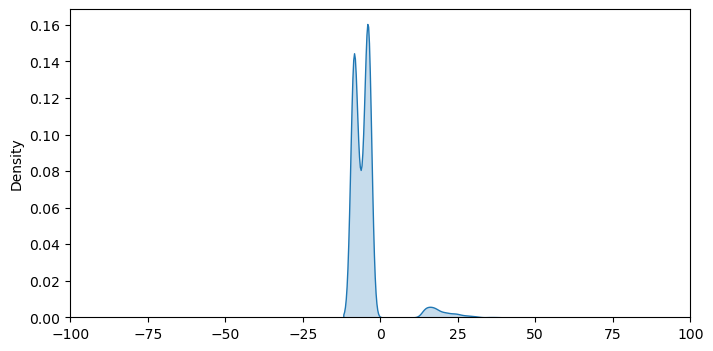

In [15]:
_ = plt.figure(figsize=(8, 4))
_ = sb.kdeplot(episode_pnl_delta,fill=True)
_ = plt.xlim([-100, 100])

In [12]:
result_processing(episode_pnl_delta, [0.05, 0.1, 0.9, 0.95])

,mean,std,Mean-SD,var5,cvar5,var10,cvar10,var90,cvar90,var95,cvar95
0,-4.320928,5.94312,-14.09736,6.091097,-5.050545,2.449836,-5.556475,-11.081257,-15.945518,-14.944991,-19.049874


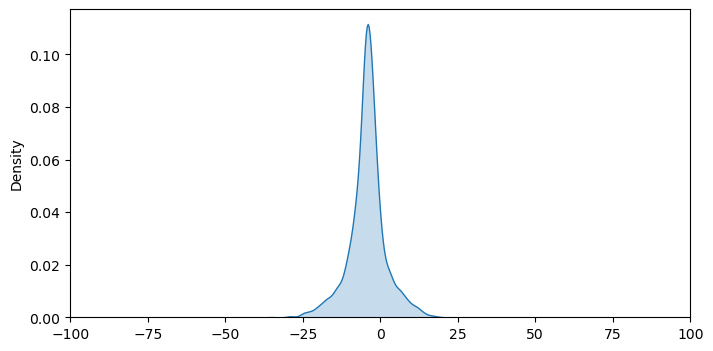

In [13]:
_ = plt.figure(figsize=(8, 4))
_ = sb.kdeplot(episode_pnl_delta,fill=True)
_ = plt.xlim([-100, 100])

In [17]:
trading_env.portfolio.risk.iloc[:50]

,pnl,delta,gamma,daily_cash,value,vega,rho,daily_pnl
2024-02-14,0.0,"A: 0.0, B: 0.0, C: 0.0","A: 0.0012257826531320726, B: 0.000737827367010...",85.31753,-85.31753,0.0,0.0,0.0
2024-02-15,-0.015229,"B: -0.0003871934736200521, C: 0.00691575090360...","B: 0.0008871007111906408, C: 0.006316942038053...",0,-85.332759,0.0,0.0,-0.015229
2024-02-16,-0.027658,"B: 0.00011644509880862942, C: 0.00217282738918...","B: 0.0007665509657609359, C: 0.006570015435418...",0,-85.345188,0.0,0.0,-0.012429
2024-02-19,-0.078119,"B: -0.00043129860422438417, C: -0.004744173935...","B: 0.000626999648926527, C: 0.0058144346672319...",0,-85.395649,0.0,0.0,-0.050461
2024-02-20,-0.087544,"B: -0.0006593084360581054, C: -0.0115251378480...","B: 0.0006300066511792596, C: 0.007652768534308...",0,-85.405074,0.0,0.0,-0.009426
2024-02-21,-0.127745,"B: 0.0008833851499147815, C: -0.00901607287840...","B: 0.0005757763347017546, C: 0.005522901015854...",0,-85.445275,0.0,0.0,-0.040201
2024-02-22,-0.140801,"B: 9.316961194764592e-05, C: -0.00322624184650...","B: 0.0006228682614965884, C: 0.004008321302808...",0,-85.458331,0.0,0.0,-0.013056
2024-02-23,-0.148858,"B: 0.0008935460490617454, C: -0.00811605145959...","B: 0.0005472710016615814, C: 0.005576469393288...",0,-85.466388,0.0,0.0,-0.008057
2024-02-26,-0.195261,"B: 0.0019931228958479296, C: -0.00704754190317...","B: 0.0005226620871321574, C: 0.004976106675146...",0,-85.512792,0.0,0.0,-0.046403
2024-02-27,-0.2068,"B: 0.002681146538443753, C: -0.008575393243028...","B: 0.000489331988896071, C: 0.0052417097855132...",0,-85.52433,0.0,0.0,-0.011539
